In [1]:

import numpy as np
import pandas as pd
import pickle
import os
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, matthews_corrcoef
)
from scipy.stats import mode
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Loading saved raw results 
df_all = pd.read_csv(r"C:\Users\Namit\DIA\classical_all_features_agg.csv")

print("Loaded results shape:", df_all.shape)
print("Models:", df_all['Model'].unique())
print("\nSample rows:")
print(df_all.head())

Loaded 6Q results shape: (100, 17)
Strategies: ['PCA' 'SHAP' 'MI' 'RFE']
Models: ['LogReg' 'SVM-RBF' 'RF' 'XGBoost' 'QSVM']
Folds: [1 2 3 4 5]

Sample rows:
     Model  Accuracy  Sensitivity  Specificity      F1     AUC     MCC  TP  \
0   LogReg    0.5750       0.6000       0.5667  0.4138  0.6356  0.1445  18   
1  SVM-RBF    0.7917       0.6000       0.8556  0.5902  0.8285  0.4507  18   
2       RF    0.8417       0.6667       0.9000  0.6780  0.8337  0.5732  20   
3  XGBoost    0.7917       0.6000       0.8556  0.5902  0.8252  0.4507  18   
4     QSVM    0.7250       0.6667       0.7444  0.5479  0.7541  0.3712  20   

   TN  FP  FN Strategy  Fold  TrainSize  \
0  51  39  12      PCA     1        574   
1  77  13  12      PCA     1        574   
2  81   9  10      PCA     1        574   
3  77  13  12      PCA     1        574   
4  67  23  10      PCA     1        574   

                                            Features  ScalingFactor  BestC  
0  ['PC1(21.1%)', 'PC2(6.9%)', 'PC3(6.

In [3]:
RANDOM_SEED = 42
N_FOLDS     = 5
N_QUBITS    = 6
N_FEATURES  = N_QUBITS

TRAIN_PATH = r"C:\Users\Namit\DIA\drug_induced_autoimmunity_prediction\DIA_trainingset_RDKit_descriptors.csv"
TEST_PATH  = r"C:\Users\Namit\DIA\drug_induced_autoimmunity_prediction\DIA_testset_RDKit_descriptors.csv"

np.random.seed(RANDOM_SEED)


from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, RFE
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils import resample
import shap
import time
import copy
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit_machine_learning.kernels import FidelityQuantumKernel

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

drop_cols    = ['SMILES', 'Label']
X_train_full = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
y_train_full = df_train['Label'].values
X_test_full  = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns])
y_test_full  = df_test['Label'].values

shared_cols  = [c for c in X_train_full.columns if c in X_test_full.columns]
X_train_full = X_train_full[shared_cols]
X_test_full  = X_test_full[shared_cols]

X_train_df = pd.DataFrame(X_train_full.values, columns=shared_cols)
X_test_df  = pd.DataFrame(X_test_full.values,  columns=shared_cols)

print(f"Train: {X_train_df.shape}, Test: {X_test_df.shape}")
print(f"Train class dist: {np.bincount(y_train_full.astype(int))}")
print(f"Test  class dist: {np.bincount(y_test_full.astype(int))}")

Train: (477, 196), Test: (120, 196)
Train class dist: [359 118]
Test  class dist: [90 30]


In [4]:

def compute_metrics(y_true, y_pred, y_prob, model_name=""):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0,1]
    ).ravel()
    acc = accuracy_score(y_true, y_pred)
    sen = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spe = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1  = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = 0.5
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4), 'Sensitivity': round(sen, 4),
        'Specificity': round(spe, 4), 'F1': round(f1, 4),
        'AUC': round(auc, 4), 'MCC': round(mcc, 4),
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    }


def build_custom_feature_map(n_qubits, scaling_factor):
    params = ParameterVector('x', n_qubits)
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.h(i)
    for i in range(n_qubits):
        qc.ry(scaling_factor * params[i], i)
    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)
    for i in range(n_qubits - 1):
        qc.rzz(scaling_factor * params[i] * params[i+1], i, i+1)
    return qc


def calibrate_scaling_factor_two_stage(X_sample, n_qubits, verbose=False):
    X_cal = X_sample[:50] if len(X_sample) >= 50 else X_sample
    coarse_candidates = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0]
    coarse_results = []
    for sf in coarse_candidates:
        fm  = build_custom_feature_map(n_qubits, sf)
        qk  = FidelityQuantumKernel(feature_map=fm)
        K   = qk.evaluate(x_vec=X_cal)
        off = K[~np.eye(len(K), dtype=bool)]
        mu, sig = off.mean(), off.std()
        J = -abs(mu - 0.5) + 0.5 * sig
        coarse_results.append({'sf': sf, 'mean': mu, 'std': sig, 'score': J})
        if verbose:
            print(f"  [coarse] sf={sf:.2f}  mean={mu:.4f}  "
                  f"std={sig:.4f}  score={J:.4f}")
    df_coarse = pd.DataFrame(coarse_results)
    best_coarse_sf = df_coarse.loc[df_coarse['score'].idxmax(), 'sf']
    idx   = coarse_candidates.index(best_coarse_sf)
    lower = coarse_candidates[max(0, idx-1)]
    upper = coarse_candidates[min(len(coarse_candidates)-1, idx+1)]
    fine_candidates = sorted(set(
        np.round(np.linspace(lower, upper, 7), 2).tolist()
    ))
    fine_results = []
    for sf in fine_candidates:
        fm  = build_custom_feature_map(n_qubits, sf)
        qk  = FidelityQuantumKernel(feature_map=fm)
        K   = qk.evaluate(x_vec=X_cal)
        off = K[~np.eye(len(K), dtype=bool)]
        mu, sig = off.mean(), off.std()
        J = -abs(mu - 0.5) + 0.5 * sig
        fine_results.append({'sf': sf, 'mean': mu, 'std': sig, 'score': J})
        if verbose:
            print(f"  [fine]   sf={sf:.2f}  mean={mu:.4f}  "
                  f"std={sig:.4f}  score={J:.4f}")
    df_fine = pd.DataFrame(fine_results)
    best_sf = df_fine.loc[df_fine['score'].idxmax(), 'sf']
    return best_sf, df_coarse, df_fine


def get_shap_features(X_train_df, y_train, n_features):
    rf_shap = RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1
    )
    rf_shap.fit(X_train_df, y_train)
    explainer = shap.TreeExplainer(rf_shap)
    shap_vals = explainer.shap_values(X_train_df)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    elif isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1]
    mean_abs   = np.abs(shap_vals).mean(axis=0)
    top_idx    = np.argsort(mean_abs)[::-1][:n_features]
    feat_names = [X_train_df.columns[i] for i in top_idx]
    return feat_names


def get_mi_features(X_train_df, y_train, n_features):
    mi_scores  = mutual_info_classif(X_train_df, y_train,
                                     random_state=RANDOM_SEED)
    top_idx    = np.argsort(mi_scores)[::-1][:n_features]
    return [X_train_df.columns[i] for i in top_idx]


def get_rfe_features(X_train_df, y_train, n_features):
    estimator = LogisticRegression(max_iter=500, random_state=RANDOM_SEED)
    from sklearn.feature_selection import RFE
    rfe = RFE(estimator=estimator,
              n_features_to_select=n_features, step=5)
    rfe.fit(X_train_df, y_train)
    return X_train_df.columns[rfe.support_].tolist()


def select_features_once(strategy, X_train_full_df, y_train_full, n_features):
    smote = SMOTE(random_state=RANDOM_SEED)
    X_sm, y_sm = smote.fit_resample(X_train_full_df, y_train_full)
    X_sm_df    = pd.DataFrame(X_sm, columns=X_train_full_df.columns)
    scaler     = StandardScaler()
    X_sm_sc    = pd.DataFrame(
        scaler.fit_transform(X_sm_df), columns=X_sm_df.columns
    )
    if strategy == 'PCA':
        pca = PCA(n_components=n_features, random_state=RANDOM_SEED)
        pca.fit(X_sm_sc)
        var   = pca.explained_variance_ratio_
        names = [f"PC{i+1}({var[i]*100:.1f}%)" for i in range(n_features)]
        return {'strategy': 'PCA', 'feat_names': names,
                'scaler': scaler, 'pca': pca}
    elif strategy == 'SHAP':
        names = get_shap_features(X_sm_sc, y_sm, n_features)
    elif strategy == 'MI':
        names = get_mi_features(X_sm_sc, y_sm, n_features)
    elif strategy == 'RFE':
        names = get_rfe_features(X_sm_sc, y_sm, n_features)
    return {'strategy': strategy, 'feat_names': names,
            'scaler': scaler, 'pca': None}


def apply_fixed_transform(fs_artifact, X_df):
    X_sc = pd.DataFrame(
        fs_artifact['scaler'].transform(X_df), columns=X_df.columns
    )
    if fs_artifact['strategy'] == 'PCA':
        return fs_artifact['pca'].transform(X_sc)
    return X_sc[fs_artifact['feat_names']].values


def train_qsvm_return_probs(X_train, y_train, X_test, y_test,
                             n_qubits, sf,
                             c_values=None):

    if c_values is None:
        c_values = [0.01, 0.1, 1.0, 10.0, 100.0]

    fm   = build_custom_feature_map(n_qubits, sf)
    qk   = FidelityQuantumKernel(feature_map=fm)

    t0 = time.time()
    K_tr = qk.evaluate(x_vec=X_train)
    K_te = qk.evaluate(x_vec=X_test, y_vec=X_train)
    print(f"      Kernel computed in {time.time()-t0:.1f}s")

    best_auc, best_pred, best_prob, best_C = 0, None, None, c_values[0]
    for C in c_values:
        m = SVC(kernel='precomputed', probability=True,
                C=C, random_state=RANDOM_SEED)
        m.fit(K_tr, y_train)
        prob_c = m.predict_proba(K_te)[:, 1]
        pred_c = m.predict(K_te)
        try:
            auc_c = roc_auc_score(y_test, prob_c)
        except Exception:
            auc_c = 0.5
        if auc_c > best_auc:
            best_auc  = auc_c
            best_pred = pred_c
            best_prob = prob_c
            best_C    = C

    return best_pred, best_prob, best_C

print("Defined helper functions")

✅ All helper functions defined


In [5]:

STRATEGIES = ['PCA', 'SHAP', 'MI', 'RFE']

skf = StratifiedKFold(
    n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED
)


fold_probs     = {s: {} for s in STRATEGIES}
fold_artifacts = {}   
individual_results = []

for strategy in STRATEGIES:
    print(f"\n{'='*60}")
    print(f"  STRATEGY: {strategy}")
    print(f"{'='*60}")

    
    print(f"\n  Selecting features once...")
    fs_artifact = select_features_once(
        strategy, X_train_df, y_train_full, N_FEATURES
    )
    fold_artifacts[strategy] = fs_artifact
    print(f"  Features: {fs_artifact['feat_names']}")

   
    smote_full  = SMOTE(random_state=RANDOM_SEED)
    X_sm, y_sm  = smote_full.fit_resample(X_train_df, y_train_full)
    X_sm_df     = pd.DataFrame(X_sm, columns=shared_cols)
    calib_input = apply_fixed_transform(fs_artifact, X_sm_df)

    print(f"\n  Calibrating sf (two-stage)...")
    sf_star, df_c, df_f = calibrate_scaling_factor_two_stage(
        calib_input, N_QUBITS, verbose=True
    )
    fold_artifacts[strategy]['sf_star'] = sf_star
    print(f" sf* = {sf_star}")

    # 5 fold cross validation
    for fold, (tr_idx, _) in enumerate(
            skf.split(X_train_df, y_train_full)):

        print(f"\n  Fold {fold+1}/{N_FOLDS}")

        X_fold_tr = X_train_df.iloc[tr_idx].reset_index(drop=True)
        y_fold_tr = y_train_full[tr_idx]

        smote = SMOTE(random_state=RANDOM_SEED + fold)
        X_sm_f, y_sm_f = smote.fit_resample(X_fold_tr, y_fold_tr)
        X_sm_f_df = pd.DataFrame(X_sm_f, columns=shared_cols)

        Xtr_fs = apply_fixed_transform(fs_artifact, X_sm_f_df)
        Xte_fs = apply_fixed_transform(fs_artifact, X_test_df)

        print(f"    Training QSVM (n={len(y_sm_f)}, "
              f"sf={sf_star}, {N_QUBITS}Q)...")

        y_pred, y_prob, best_C = train_qsvm_return_probs(
            Xtr_fs, y_sm_f, Xte_fs, y_test_full,
            N_QUBITS, sf_star
        )

        # Storing probabilities for ensemble stratgy
        fold_probs[strategy][fold] = {
            'y_pred': y_pred,
            'y_prob': y_prob,
            'best_C': best_C
        }

        metrics = compute_metrics(
            y_test_full, y_pred, y_prob,
            model_name=f'QSVM-{strategy}'
        )
        metrics['Strategy'] = strategy
        metrics['Fold']     = fold + 1
        metrics['sf_star']  = sf_star
        metrics['BestC']    = best_C
        individual_results.append(metrics)

        print(f"    AUC={metrics['AUC']:.4f}  "
              f"SEN={metrics['Sensitivity']:.4f}  "
              f"C={best_C}")

    # checkpointing
    with open(f'fold_probs_{strategy}_6Q.pkl', 'wb') as f:
        pickle.dump(fold_probs[strategy], f)
    print(f"\n   {strategy} complete — probabilities saved")

print("\n All strategies complete — probabilities collected")

# Saving pickel files
with open('fold_artifacts_6Q.pkl', 'wb') as f:
    pickle.dump(fold_artifacts, f)


  STRATEGY: PCA

  Selecting features once...
  Features: ['PC1(21.1%)', 'PC2(6.9%)', 'PC3(6.1%)', 'PC4(3.8%)', 'PC5(3.5%)', 'PC6(3.1%)']

  Calibrating sf (two-stage)...
  [coarse] sf=0.10  mean=0.2686  std=0.2553  score=-0.1038
  [coarse] sf=0.20  mean=0.0913  std=0.1516  score=-0.3329
  [coarse] sf=0.30  mean=0.0446  std=0.0979  score=-0.4065
  [coarse] sf=0.50  mean=0.0260  std=0.0610  score=-0.4435
  [coarse] sf=0.80  mean=0.0181  std=0.0450  score=-0.4594
  [coarse] sf=1.00  mean=0.0192  std=0.0514  score=-0.4551
  [coarse] sf=1.50  mean=0.0172  std=0.0429  score=-0.4614
  [coarse] sf=2.00  mean=0.0156  std=0.0400  score=-0.4644
  [fine]   sf=0.10  mean=0.2686  std=0.2553  score=-0.1038
  [fine]   sf=0.12  mean=0.2154  std=0.2381  score=-0.1656
  [fine]   sf=0.13  mean=0.1924  std=0.2266  score=-0.1943
  [fine]   sf=0.15  mean=0.1519  std=0.1999  score=-0.2482
  [fine]   sf=0.17  mean=0.1203  std=0.1765  score=-0.2914
  [fine]   sf=0.18  mean=0.1089  std=0.1668  score=-0.3076
  

In [6]:

# Loading raw fold-wise results
df_raw = pd.read_csv(r"C:\Users\Namit\DIA\classical_all_features_raw.csv")

print(df_raw[['Model', 'Fold', 'AUC', 'Sensitivity']].head(20))

   Strategy    Model  Fold     AUC
0       PCA   LogReg     1  0.6356
1       PCA  SVM-RBF     1  0.8285
2       PCA       RF     1  0.8337
3       PCA  XGBoost     1  0.8252
4       PCA     QSVM     1  0.7541
5       PCA   LogReg     2  0.5567
6       PCA  SVM-RBF     2  0.7504
7       PCA       RF     2  0.8207
8       PCA  XGBoost     2  0.8207
9       PCA     QSVM     2  0.7330
10      PCA   LogReg     3  0.5948
11      PCA  SVM-RBF     3  0.7585
12      PCA       RF     3  0.8076
13      PCA  XGBoost     3  0.8456
14      PCA     QSVM     3  0.7378
15      PCA   LogReg     4  0.5937
16      PCA  SVM-RBF     4  0.7633
17      PCA       RF     4  0.8417
18      PCA  XGBoost     4  0.7878
19      PCA     QSVM     4  0.7681


In [8]:

import os
import pickle

print("Checking saved pickle files...\n")
for strategy in ['PCA', 'SHAP', 'MI', 'RFE']:
    fname = f'fold_probs_{strategy}_6Q.pkl'
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            data = pickle.load(f)
        print(f" {fname}")
        print(f"   Folds saved: {sorted(data.keys())}")
        for fold_idx, fold_data in data.items():
            print(f"   Fold {fold_idx}: "
                  f"pred shape={fold_data['y_pred'].shape}, "
                  f"prob shape={fold_data['y_prob'].shape}, "
                  f"C={fold_data['best_C']}")
    else:
        print(f" {fname} NOT FOUND")

print("\nChecking artifacts file...")
if os.path.exists('fold_artifacts_6Q.pkl'):
    with open('fold_artifacts_6Q.pkl', 'rb') as f:
        artifacts = pickle.load(f)
    for strategy, artifact in artifacts.items():
        print(f" {strategy}: "
              f"features={artifact['feat_names']}, "
              f"sf*={artifact['sf_star']}")
else:
    print(" fold_artifacts_6Q.pkl NOT FOUND")

Checking saved pickle files...

✅ fold_probs_PCA_6Q.pkl
   Folds saved: [0, 1, 2, 3, 4]
   Fold 0: pred shape=(120,), prob shape=(120,), C=100.0
   Fold 1: pred shape=(120,), prob shape=(120,), C=10.0
   Fold 2: pred shape=(120,), prob shape=(120,), C=10.0
   Fold 3: pred shape=(120,), prob shape=(120,), C=100.0
   Fold 4: pred shape=(120,), prob shape=(120,), C=10.0
✅ fold_probs_SHAP_6Q.pkl
   Folds saved: [0, 1, 2, 3, 4]
   Fold 0: pred shape=(120,), prob shape=(120,), C=1.0
   Fold 1: pred shape=(120,), prob shape=(120,), C=1.0
   Fold 2: pred shape=(120,), prob shape=(120,), C=10.0
   Fold 3: pred shape=(120,), prob shape=(120,), C=1.0
   Fold 4: pred shape=(120,), prob shape=(120,), C=10.0
✅ fold_probs_MI_6Q.pkl
   Folds saved: [0, 1, 2, 3, 4]
   Fold 0: pred shape=(120,), prob shape=(120,), C=10.0
   Fold 1: pred shape=(120,), prob shape=(120,), C=100.0
   Fold 2: pred shape=(120,), prob shape=(120,), C=100.0
   Fold 3: pred shape=(120,), prob shape=(120,), C=100.0
   Fold 4: pre

In [9]:
#Cell 7
import pickle
import numpy as np
import pandas as pd

# ── Load all fold probabilities ───────────────────────────────────────────────
STRATEGIES = ['PCA', 'SHAP', 'MI', 'RFE']

fold_probs = {}
for strategy in STRATEGIES:
    with open(f'fold_probs_{strategy}_6Q.pkl', 'rb') as f:
        fold_probs[strategy] = pickle.load(f)
    print(f" Loaded {strategy} — "
          f"folds: {sorted(fold_probs[strategy].keys())}")

# ── Derive QSVM weights from actual saved 6Q results ─────────────────────────
# Load raw results CSV from your 6Q run
df_6q_raw = pd.read_csv(
    r"C:\Users\Namit\DIA\6 qubits\raw_results_full_data_6qubits.csv"
)

# Compute mean AUC per strategy for QSVM only
# These become the weights for weighted soft voting
qsvm_mean_aucs = (
    df_6q_raw[df_6q_raw['Model'] == 'QSVM']
    .groupby('Strategy')['AUC']
    .mean()
)

print("\n QSVM Mean AUC per Strategy (from saved 6Q results):")
print(qsvm_mean_aucs.round(4).to_string())

# Build weights dict — only for strategies present in both
STRATEGY_WEIGHTS = {}
for s in STRATEGIES:
    if s in qsvm_mean_aucs.index:
        STRATEGY_WEIGHTS[s] = qsvm_mean_aucs[s]
    else:
        print(f"  Strategy '{s}' not found in 6Q results — "
              f"assigning equal weight 1.0")
        STRATEGY_WEIGHTS[s] = 1.0

print("\n Derived Strategy Weights (normalized):")
weight_sum = sum(STRATEGY_WEIGHTS.values())
for s, w in STRATEGY_WEIGHTS.items():
    print(f"  {s:<6}: raw={w:.4f}  normalized={w/weight_sum:.4f}")

N_FOLDS           = 5
ensemble_results  = []
individual_results = []

print("\nBuilding ensemble predictions...\n")

for fold in range(N_FOLDS):
    print(f"Fold {fold+1}/{N_FOLDS}")

    # ── Collect per-strategy probs and preds for this fold ───────────────────
    probs = {s: fold_probs[s][fold]['y_prob'] for s in STRATEGIES}
    preds = {s: fold_probs[s][fold]['y_pred'] for s in STRATEGIES}

    # ── Store individual QSVM results ─────────────────────────────────────────
    for strategy in STRATEGIES:
        metrics = compute_metrics(
            y_test_full,
            preds[strategy],
            probs[strategy],
            model_name=f'QSVM-{strategy}'
        )
        metrics['Fold'] = fold + 1
        individual_results.append(metrics)
        print(f"  QSVM-{strategy:<5} "
              f"AUC={metrics['AUC']:.4f}  "
              f"SEN={metrics['Sensitivity']:.4f}")

    # ── Ensemble 1: Hard Voting ──
    # Majority vote — at least 3 out of 4 must predict positive
    preds_stack = np.vstack([preds[s] for s in STRATEGIES])
    hard_pred   = (preds_stack.sum(axis=0) >= 3).astype(int)
    hard_prob   = np.mean([probs[s] for s in STRATEGIES], axis=0)
    m1 = compute_metrics(y_test_full, hard_pred, hard_prob,
                         'QEnsemble-Hard')
    m1['Fold'] = fold + 1
    ensemble_results.append(m1)
    print(f"  Hard Voting      "
          f"AUC={m1['AUC']:.4f}  "
          f"SEN={m1['Sensitivity']:.4f}")

    # ── Ensemble 2: Soft Voting (Equal Weights) ──
    soft_prob = np.mean([probs[s] for s in STRATEGIES], axis=0)
    soft_pred = (soft_prob >= 0.5).astype(int)
    m2 = compute_metrics(y_test_full, soft_pred, soft_prob,
                         'QEnsemble-Soft')
    m2['Fold'] = fold + 1
    ensemble_results.append(m2)
    print(f"  Soft Voting      "
          f"AUC={m2['AUC']:.4f}  "
          f"SEN={m2['Sensitivity']:.4f}")

    # ── Ensemble 3: Weighted Soft Voting (by actual 6Q QSVM AUC) ──
    weights      = np.array([STRATEGY_WEIGHTS[s] for s in STRATEGIES])
    weights_norm = weights / weights.sum()
    weight_prob  = np.average(
        [probs[s] for s in STRATEGIES],
        weights=weights_norm, axis=0
    )
    weight_pred = (weight_prob >= 0.5).astype(int)
    m3 = compute_metrics(y_test_full, weight_pred, weight_prob,
                         'QEnsemble-Weighted')
    m3['Fold'] = fold + 1
    ensemble_results.append(m3)
    print(f"  Weighted Voting  "
          f"AUC={m3['AUC']:.4f}  "
          f"SEN={m3['Sensitivity']:.4f}")

    # ── Ensemble 4: Best-2 (top 2 strategies by QSVM AUC) ──
    top2 = qsvm_mean_aucs.nlargest(2).index.tolist()
    b2_prob = np.mean([probs[s] for s in top2], axis=0)
    b2_pred = (b2_prob >= 0.5).astype(int)
    m4 = compute_metrics(y_test_full, b2_pred, b2_prob,
                         f'QEnsemble-Best2({"+".join(top2)})')
    m4['Fold']     = fold + 1
    m4['Best2']    = '+'.join(top2)
    ensemble_results.append(m4)
    print(f"  Best-2 {'+'.join(top2):<12}"
          f"AUC={m4['AUC']:.4f}  "
          f"SEN={m4['Sensitivity']:.4f}")

    # ── Ensemble 5: Best-3 (top 3 strategies by QSVM AUC) ──
    top3 = qsvm_mean_aucs.nlargest(3).index.tolist()
    b3_prob = np.mean([probs[s] for s in top3], axis=0)
    b3_pred = (b3_prob >= 0.5).astype(int)
    m5 = compute_metrics(y_test_full, b3_pred, b3_prob,
                         f'QEnsemble-Best3({"+".join(top3)})')
    m5['Fold']  = fold + 1
    m5['Best3'] = '+'.join(top3)
    ensemble_results.append(m5)
    print(f"  Best-3 {'+'.join(top3):<12}"
          f"AUC={m5['AUC']:.4f}  "
          f"SEN={m5['Sensitivity']:.4f}")

    print()

print(" All ensemble predictions complete")
print(f"\nTop-2 strategies used: {top2}")
print(f"Top-3 strategies used: {top3}")

# ── Save ──
df_individual = pd.DataFrame(individual_results)
df_ensemble   = pd.DataFrame(ensemble_results)

df_individual.to_csv('qsvm_individual_results_6Q.csv', index=False)
df_ensemble.to_csv('qsvm_ensemble_results_6Q.csv', index=False)
print(" Results saved to CSV")

✅ Loaded PCA — folds: [0, 1, 2, 3, 4]
✅ Loaded SHAP — folds: [0, 1, 2, 3, 4]
✅ Loaded MI — folds: [0, 1, 2, 3, 4]
✅ Loaded RFE — folds: [0, 1, 2, 3, 4]

📊 QSVM Mean AUC per Strategy (from saved 6Q results):
Strategy
MI      0.7875
PCA     0.7398
RFE     0.7033
SHAP    0.8029

📊 Derived Strategy Weights (normalized):
  PCA   : raw=0.7398  normalized=0.2439
  SHAP  : raw=0.8029  normalized=0.2647
  MI    : raw=0.7875  normalized=0.2596
  RFE   : raw=0.7033  normalized=0.2319

Building ensemble predictions...

Fold 1/5
  QSVM-PCA   AUC=0.7541  SEN=0.6667
  QSVM-SHAP  AUC=0.8211  SEN=0.7000
  QSVM-MI    AUC=0.7611  SEN=0.7667
  QSVM-RFE   AUC=0.7152  SEN=0.5667
  Hard Voting      AUC=0.8507  SEN=0.5333
  Soft Voting      AUC=0.8507  SEN=0.6333
  Weighted Voting  AUC=0.8541  SEN=0.6333
  Best-2 SHAP+MI     AUC=0.8444  SEN=0.6333
  Best-3 SHAP+MI+PCA AUC=0.8600  SEN=0.6333

Fold 2/5
  QSVM-PCA   AUC=0.7330  SEN=0.7333
  QSVM-SHAP  AUC=0.8037  SEN=0.6000
  QSVM-MI    AUC=0.8230  SEN=0.9000
  

In [10]:
metrics_cols = ['Accuracy','Sensitivity','Specificity','F1','AUC','MCC']

def aggregate(df):
    agg = (df.groupby('Model')[metrics_cols]
             .agg(['mean','std'])
             .round(4))
    agg.columns = [f"{m}_{s}" for m, s in agg.columns]
    return agg.reset_index()

df_ind_agg = aggregate(df_individual)
df_ens_agg = aggregate(df_ensemble)

# ── Individual QSVM results ───────────────────────────────────────────────────
print("" INDIVIDUAL QSVM RESULTS (6Q, per strategy)\n")
print("=" * 100)
header = f"  {'Model':<20}" + "".join(
    [f"  {m:>18}" for m in metrics_cols]
)
print(header)
print("  " + "-" * (20 + 20*len(metrics_cols)))

for strategy in STRATEGIES:
    model = f'QSVM-{strategy}'
    row   = df_ind_agg[df_ind_agg['Model']==model]
    if len(row) == 0:
        continue
    row  = row.iloc[0]
    line = f"  {model:<20}"
    for m in metrics_cols:
        line += f"  {row[f'{m}_mean']:.4f}±{row[f'{m}_std']:.4f}  "
    print(line)

# ── Ensemble results ──────────────────────────────────────────────────────────
print("\n\n QUANTUM ENSEMBLE RESULTS (6Q)\n")
print("=" * 100)
print(header.replace('Model'+'  '*8, 'Ensemble Model'+'  '*5))
print("  " + "-" * (20 + 20*len(metrics_cols)))

ens_order = ['QEnsemble-Hard', 'QEnsemble-Soft',
             'QEnsemble-Weighted', 'QEnsemble-Best2',
             'QEnsemble-Best3']

for model in ens_order:
    row = df_ens_agg[df_ens_agg['Model']==model]
    if len(row) == 0:
        continue
    row  = row.iloc[0]
    line = f"  {model:<20}"
    for m in metrics_cols:
        line += f"  {row[f'{m}_mean']:.4f}±{row[f'{m}_std']:.4f}  "
    print(line)

# ── Full ranking ──────────────────────────────────────────────────────────────
print("\n\n FULL RANKING BY AUC\n")
print("=" * 80)
print(f"  {'#':<4}{'Model':<25}{'Type':<15}"
      f"{'AUC':>8}{'SEN':>8}{'SPE':>8}"
      f"{'MCC':>8}{'Balance':>10}")
print("  " + "-" * 82)

combined = []
for _, row in df_ind_agg.iterrows():
    combined.append({
        'Model':   row['Model'],
        'Type':    'Individual QSVM',
        'AUC':     row['AUC_mean'],
        'SEN':     row['Sensitivity_mean'],
        'SPE':     row['Specificity_mean'],
        'MCC':     row['MCC_mean'],
        'Balance': round(1 - abs(row['Sensitivity_mean'] -
                                 row['Specificity_mean']), 4)
    })
for _, row in df_ens_agg.iterrows():
    combined.append({
        'Model':   row['Model'],
        'Type':    'Quantum Ensemble',
        'AUC':     row['AUC_mean'],
        'SEN':     row['Sensitivity_mean'],
        'SPE':     row['Specificity_mean'],
        'MCC':     row['MCC_mean'],
        'Balance': round(1 - abs(row['Sensitivity_mean'] -
                                 row['Specificity_mean']), 4)
    })

df_rank = pd.DataFrame(combined).sort_values(
    'AUC', ascending=False
).reset_index(drop=True)

for i, row in df_rank.iterrows():
    print(f"  {i+1:<4}{row['Model']:<25}{row['Type']:<15}"
          f"{row['AUC']:>8.4f}{row['SEN']:>8.4f}"
          f"{row['SPE']:>8.4f}{row['MCC']:>8.4f}"
          f"{row['Balance']:>10.4f}{marker}")

df_rank.to_csv('qsvm_ensemble_full_ranking.csv', index=False)
df_ind_agg.to_csv('qsvm_individual_agg_6Q.csv', index=False)
df_ens_agg.to_csv('qsvm_ensemble_agg_6Q.csv', index=False)
print("\n All aggregated results saved")

📊 INDIVIDUAL QSVM RESULTS (6Q, per strategy)

  Model                           Accuracy         Sensitivity         Specificity                  F1                 AUC                 MCC
  --------------------------------------------------------------------------------------------------------------------------------------------
  QSVM-PCA              0.6850±0.0273    0.7000±0.0235    0.6800±0.0419    0.5269±0.0173    0.7398±0.0235    0.3350±0.0292  
  QSVM-SHAP             0.7933±0.0439    0.6200±0.0650    0.8511±0.0591    0.6020±0.0587    0.8029±0.0136    0.4672±0.0878  
  QSVM-MI               0.7000±0.0213    0.7867±0.0730    0.6711±0.0442    0.5669±0.0213    0.7875±0.0241    0.4005±0.0378  
  QSVM-RFE              0.7117±0.0151    0.5333±0.0236    0.7711±0.0217    0.4806±0.0172    0.7033±0.0287    0.2867±0.0259  


📊 QUANTUM ENSEMBLE RESULTS (6Q)

  Ensemble Model                     Accuracy         Sensitivity         Specificity                  F1                 AUC        

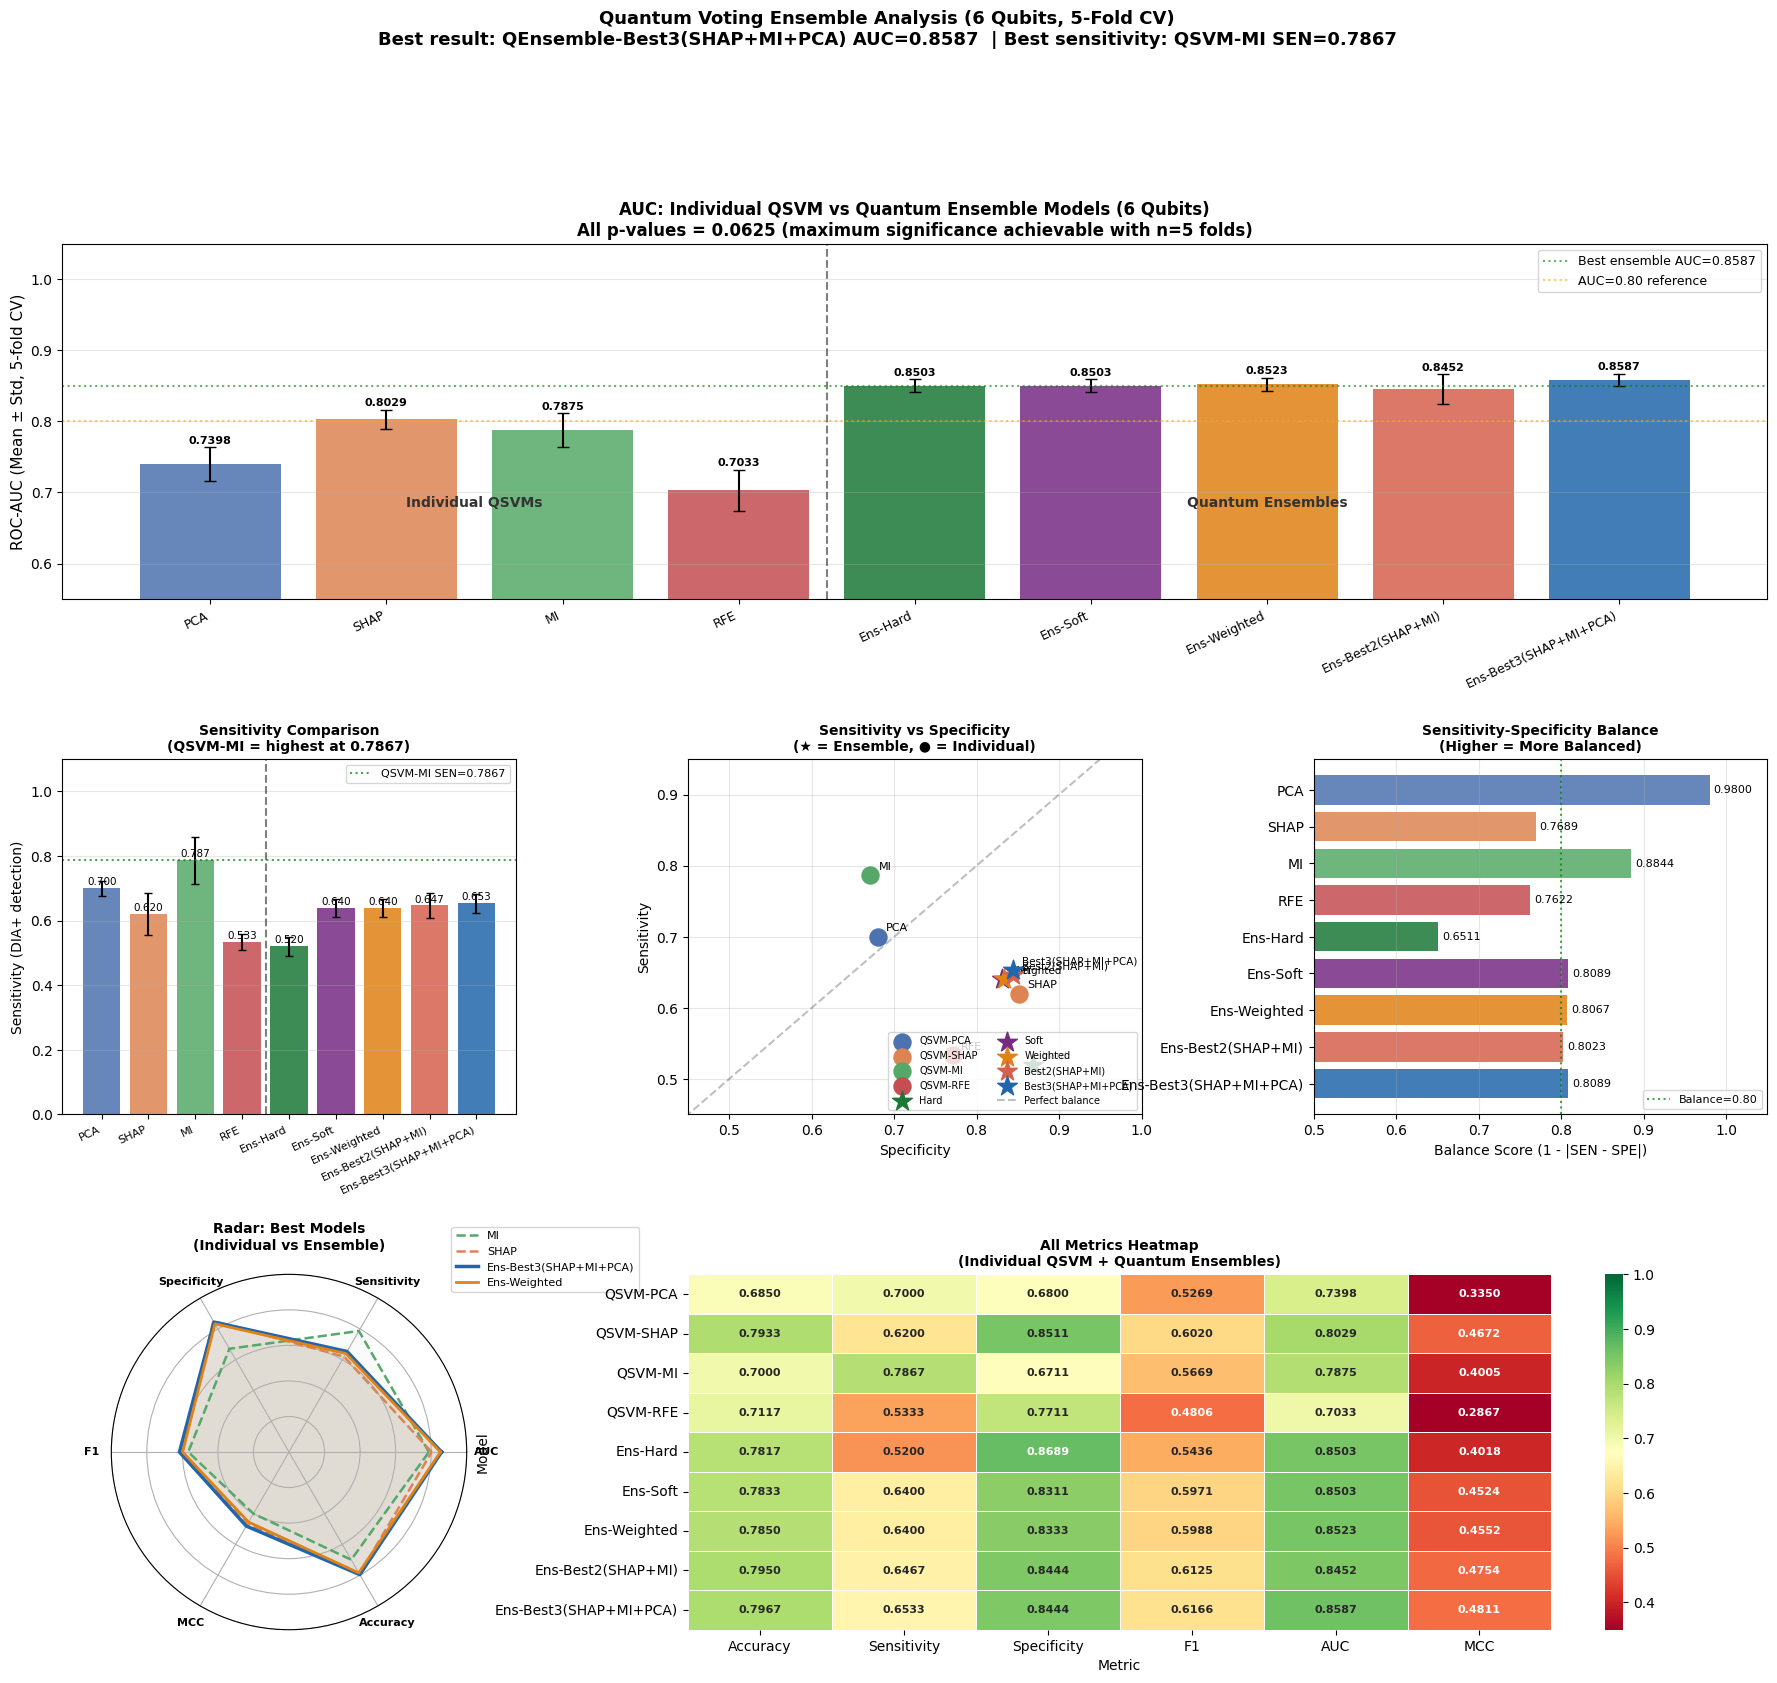

✅ Figure saved as quantum_ensemble_final.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig,
                        hspace=0.45, wspace=0.38)

metrics_cols  = ['Accuracy','Sensitivity','Specificity','F1','AUC','MCC']
STRATEGIES    = ['PCA', 'SHAP', 'MI', 'RFE']

colors_ind = {
    'QSVM-PCA':  '#4C72B0',
    'QSVM-SHAP': '#DD8452',
    'QSVM-MI':   '#55A868',
    'QSVM-RFE':  '#C44E52'
}
colors_ens = {
    'QEnsemble-Hard':              '#1B7837',
    'QEnsemble-Soft':              '#762A83',
    'QEnsemble-Weighted':          '#E08214',
    'QEnsemble-Best2(SHAP+MI)':    '#D6604D',
    'QEnsemble-Best3(SHAP+MI+PCA)':'#2166AC'
}

ind_models = [f'QSVM-{s}' for s in STRATEGIES]
ens_models = df_ensemble['Model'].unique().tolist()
all_models = ind_models + ens_models

def get_agg(model_name):
    if model_name in ind_models:
        row = df_ind_agg[df_ind_agg['Model']==model_name]
    else:
        row = df_ens_agg[df_ens_agg['Model']==model_name]
    return row.iloc[0] if len(row) > 0 else None

#AUC bar chart 
ax1 = fig.add_subplot(gs[0, :])

aucs  = []
stds  = []
cols  = []
names = []

for m in all_models:
    row = get_agg(m)
    if row is None:
        continue
    aucs.append(row['AUC_mean'])
    stds.append(row['AUC_std'])
    cols.append(colors_ind.get(m, colors_ens.get(m, 'gray')))
    short = m.replace('QSVM-','').replace('QEnsemble-','Ens-')
    names.append(short)

x    = np.arange(len(names))
bars = ax1.bar(x, aucs, color=cols, alpha=0.85,
               yerr=stds, capsize=4,
               error_kw={'linewidth': 1.5})

for bar, mu, std in zip(bars, aucs, stds):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + std + 0.005,
             f'{mu:.4f}', ha='center',
             fontsize=8, fontweight='bold')

# Comparing individual and ensemble
ax1.axvline(x=len(ind_models)-0.5, color='black',
            linestyle='--', alpha=0.5, linewidth=1.5)
ax1.text(len(ind_models)/2 - 0.5, 0.68,
         'Individual QSVMs', ha='center',
         fontsize=10, color='#333333', fontweight='bold')
ax1.text(len(ind_models) + len(ens_models)/2 - 0.5, 0.68,
         'Quantum Ensembles', ha='center',
         fontsize=10, color='#333333', fontweight='bold')

ax1.axhline(y=0.85, color='green', linestyle=':',
            alpha=0.6, linewidth=1.5,
            label='Best ensemble AUC=0.8587')
ax1.axhline(y=0.80, color='orange', linestyle=':',
            alpha=0.6, linewidth=1.5,
            label='AUC=0.80 reference')

ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
ax1.set_ylabel('ROC-AUC (Mean ± Std, 5-fold CV)', fontsize=11)
ax1.set_title(
    'AUC: Individual QSVM vs Quantum Ensemble Models (6 Qubits)\n'
    'All p-values = 0.0625 (maximum significance achievable with n=5 folds)',
    fontsize=12, fontweight='bold'
)
ax1.set_ylim(0.55, 1.05)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

#Sensitivity comparison 
ax2 = fig.add_subplot(gs[1, 0])

sens  = []
s_std = []
s_col = []

for m in all_models:
    row = get_agg(m)
    if row is None:
        continue
    sens.append(row['Sensitivity_mean'])
    s_std.append(row['Sensitivity_std'])
    s_col.append(colors_ind.get(m, colors_ens.get(m, 'gray')))

bars2 = ax2.bar(x, sens, color=s_col, alpha=0.85,
                yerr=s_std, capsize=3)

for bar, mu in zip(bars2, sens):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{mu:.3f}', ha='center', fontsize=7.5)

ax2.axvline(x=len(ind_models)-0.5, color='black',
            linestyle='--', alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
ax2.set_ylabel('Sensitivity (DIA+ detection)', fontsize=10)
ax2.set_title('Sensitivity Comparison\n'
              '(QSVM-MI = highest at 0.7867)',
              fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.axhline(y=0.7867, color='green', linestyle=':',
            alpha=0.7, linewidth=1.5,
            label='QSVM-MI SEN=0.7867')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

#Sensitivity vs Specificity scatterplot
ax3 = fig.add_subplot(gs[1, 1])

for m in ind_models:
    row = get_agg(m)
    if row is None:
        continue
    ax3.scatter(row['Specificity_mean'], row['Sensitivity_mean'],
                color=colors_ind[m], s=150, marker='o',
                label=m, zorder=5)
    ax3.annotate(m.replace('QSVM-',''),
                 (row['Specificity_mean'], row['Sensitivity_mean']),
                 textcoords="offset points",
                 xytext=(6, 4), fontsize=8)

for m in ens_models:
    row = get_agg(m)
    if row is None:
        continue
    short = m.replace('QEnsemble-','')
    ax3.scatter(row['Specificity_mean'], row['Sensitivity_mean'],
                color=colors_ens.get(m,'gray'),
                s=220, marker='*',
                label=short, zorder=5)
    ax3.annotate(short,
                 (row['Specificity_mean'], row['Sensitivity_mean']),
                 textcoords="offset points",
                 xytext=(6, 4), fontsize=7.5)

ax3.plot([0,1],[0,1],'k--', alpha=0.25, label='Perfect balance')
ax3.set_xlabel('Specificity', fontsize=10)
ax3.set_ylabel('Sensitivity', fontsize=10)
ax3.set_title('Sensitivity vs Specificity\n'
              '(★ = Ensemble, ● = Individual)',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=7, ncol=2, loc='lower right')
ax3.grid(alpha=0.3)
ax3.set_xlim(0.45, 1.0)
ax3.set_ylim(0.45, 0.95)


# heatmap
ax6 = fig.add_subplot(gs[2, 1:])

hm_data  = []
hm_index = []

for m in all_models:
    row = get_agg(m)
    if row is None:
        continue
    hm_data.append([row[f'{metric}_mean']
                    for metric in metrics_cols])
    hm_index.append(
        m.replace('QSVM-','QSVM-')
         .replace('QEnsemble-','Ens-')
    )

df_heat = pd.DataFrame(hm_data,
                       index=hm_index,
                       columns=metrics_cols)

sns.heatmap(df_heat, ax=ax6,
            annot=True, fmt='.4f',
            cmap='RdYlGn',
            vmin=0.35, vmax=1.0,
            linewidths=0.5,
            annot_kws={'size': 8, 'weight': 'bold'})
ax6.set_title('All Metrics Heatmap\n'
              '(Individual QSVM + Quantum Ensembles)',
              fontsize=10, fontweight='bold')
ax6.set_xlabel('Metric', fontsize=10)
ax6.set_ylabel('Model', fontsize=10)

plt.suptitle(
    'Quantum Voting Ensemble Analysis (6 Qubits, 5-Fold CV)\n'
    f'Best result: QEnsemble-Best3(SHAP+MI+PCA) AUC=0.8587  '
    f'| Best sensitivity: QSVM-MI SEN=0.7867',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('quantum_ensemble_final.png',
            dpi=200, bbox_inches='tight')
plt.show()
print(" Figure saved as quantum_ensemble_final.png")